## Apple Watch Telemetry Anomaly Detection
### Unified Anomaly Intelligence Framework v3.0 — Production Build

```
Apple Watch Telemetry
   |
Multi-Layer Signals (HR, ECG, GPS, Battery, CPU, NFC)
   |
Phase 1: Models of Normal  (Rolling Mean · ARIMA · Autoencoder)
   |
Phase 2: Anomaly Detection  (Sigma Threshold · RRCF · Dynamic Threshold)
   |
LLM Root Cause Engine  (Groq / Llama-3 — Free Tier)
```

### Scenarios
| # | Scenario | Key Signals | Stakes |
|---|----------|------------|--------|
| 1 | AFib Miss | ecg_noise, signal_quality, afib_flag | Clinical / Life Safety |
| 2 | Apple Pay Failure | nfc_latency, api_latency, payment_status | Revenue / SLA |
| 3 | False Emergency SOS | g_force, wrist_velocity, context | Legal / Trust |
| 4 | Battery Drain | battery_pct, cpu_pct, bg_wakeups | Reliability / Safety |

---
**LLM:** Groq free tier (llama-3.1-8b-instant). Get a free API key at https://console.groq.com  
**Dataset storage:** `./data/raw/` (per-scenario CSVs) + `./data/processed/` (unified schema + metadata JSON)

## Cell 0 — Setup and Imports

In [1]:
# ============================================================
# CELL 0.1 — Install dependencies (run once)
# ============================================================
!pip install rrcf statsmodels groq scikit-learn matplotlib seaborn pandas numpy scipy

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: C:\Users\mnaik\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [2]:
# ============================================================
# CELL 0.2 — Core imports and production configuration
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
import json
import os
import logging
import time
import hashlib
from pathlib import Path
from datetime import datetime
from dataclasses import dataclass, asdict
from typing import Dict, Tuple, Optional, List

from statsmodels.tsa.arima.model import ARIMA
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.metrics import precision_score, recall_score, f1_score
from scipy.interpolate import interp1d
import rrcf
from groq import Groq

warnings.filterwarnings('ignore')
np.random.seed(42)

# ── Logging (production-grade) ────────────────────────────────────────────────
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s | %(levelname)-8s | %(name)s | %(message)s',
    datefmt='%Y-%m-%d %H:%M:%S',
)
logger = logging.getLogger('AppleWatchAnomalyPipeline')

# ── Global Config ─────────────────────────────────────────────────────────────
@dataclass
class PipelineConfig:
    # LLM
    groq_model: str        = 'llama-3.1-8b-instant'   # Free, fast
    llm_max_tokens: int    = 400
    llm_temperature: float = 0.1                       # Low for determinism
    llm_retries: int       = 3
    llm_retry_delay: float = 2.0                       # Seconds between retries

    # Anomaly detection
    sigma_window: int      = 30
    sigma_n: float         = 2.5
    rrcf_trees: int        = 40
    rrcf_shingle: int      = 8
    rrcf_tree_size: int    = 256
    ae_latent_dim: int     = 4
    ae_window: int         = 16
    ensemble_threshold: int = 2   # Min detectors to agree for ensemble flag
    score_percentile: float = 95.0

    # Data paths
    data_root: str         = './data'
    raw_dir: str           = './data/raw'
    processed_dir: str     = './data/processed'
    run_timestamp: str     = datetime.now().strftime('%Y%m%d_%H%M%S')

CFG = PipelineConfig()

# ── Ensure data directories exist ────────────────────────────────────────────
for d in [CFG.raw_dir, CFG.processed_dir]:
    Path(d).mkdir(parents=True, exist_ok=True)

# ── Plot styling ──────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor': '#0D1117',
    'axes.facecolor':   '#131E33',
    'axes.edgecolor':   '#1E3054',
    'axes.labelcolor':  '#E8EDF5',
    'xtick.color':      '#8899BB',
    'ytick.color':      '#8899BB',
    'text.color':       '#E8EDF5',
    'grid.color':       '#1E3054',
    'grid.linewidth':   0.6,
    'legend.facecolor': '#0F1829',
    'legend.edgecolor': '#1E3054',
    'font.family':      'DejaVu Sans',
    'font.size':        11,
})

COLORS = {
    'normal':  '#1DB3B3',
    'anomaly': '#E8455A',
    'warning': '#F59E0B',
    'safe':    '#34C85A',
    'blue':    '#4B5FAA',
    'white':   '#E8EDF5',
    'muted':   '#8899BB',
    'border':  '#1E3054',
}

logger.info('Configuration loaded — model=%s, data_root=%s', CFG.groq_model, CFG.data_root)
logger.info('Run ID: %s', CFG.run_timestamp)
print('[OK] Imports and config complete.')

C:\Users\mnaik\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\rrcf\__init__.py:3: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
2026-05-06 11:10:59 | INFO     | AppleWatchAnomalyPipeline | Configuration loaded — model=llama-3.1-8b-instant, data_root=./data
2026-05-06 11:10:59 | INFO     | AppleWatchAnomalyPipeline | Run ID: 20260506_111059


[OK] Imports and config complete.


In [ ]:
# ============================================================
# CELL 0.3 — Groq API key setup
# ============================================================
# Set your free Groq API key:
#   Option A (recommended): export GROQ_API_KEY=gsk_... in your shell
#   Option B: uncomment the line below

os.environ['GROQ_API_KEY'] = '<GROC API SECRET KEY - PASTE HERE>'

GROQ_API_KEY = os.environ.get('GROQ_API_KEY', '')
if not GROQ_API_KEY:
    logger.warning(
        'GROQ_API_KEY not set. LLM root-cause cells will be skipped. '
        'Get a free key at https://console.groq.com'
    )
    LLM_AVAILABLE = False
else:
    LLM_AVAILABLE = True
    logger.info('Groq API key found — LLM root-cause engine enabled.')

print(f'[OK] LLM available: {LLM_AVAILABLE}')

2026-05-06 11:15:09 | INFO     | AppleWatchAnomalyPipeline | Groq API key found — LLM root-cause engine enabled.


[OK] LLM available: True


## Cell 1 — Shared Utilities

In [5]:
# ============================================================
# CELL 1.1 — Detection algorithms
# ============================================================

def sigma_threshold(
    series: np.ndarray,
    window: int = CFG.sigma_window,
    n_sigma: float = CFG.sigma_n
) -> Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    """Rolling sigma anomaly scorer.

    Returns
    -------
    scores, anomaly_flags, upper_band, lower_band, roll_mean
    """
    s = pd.Series(series)
    roll_mean = s.rolling(window, min_periods=1).mean()
    roll_std  = s.rolling(window, min_periods=1).std().fillna(0)
    upper = roll_mean + n_sigma * roll_std
    lower = roll_mean - n_sigma * roll_std
    flags  = ((s > upper) | (s < lower)).astype(int)
    scores = ((s - roll_mean) / (roll_std + 1e-9)).abs()
    return scores.values, flags.values, upper.values, lower.values, roll_mean.values


def fit_rrcf(
    series: np.ndarray,
    num_trees: int   = CFG.rrcf_trees,
    shingle_size: int = CFG.rrcf_shingle,
    tree_size: int   = CFG.rrcf_tree_size
) -> np.ndarray:
    """Robust Random Cut Forest anomaly scores (CoDisp)."""
    points = np.array([
        series[i:i + shingle_size]
        for i in range(len(series) - shingle_size + 1)
    ])
    forest = [rrcf.RCTree() for _ in range(num_trees)]
    avg_codisp = np.zeros(len(points))

    for tree in forest:
        indices = np.random.choice(len(points), size=min(tree_size, len(points)), replace=False)
        for idx in indices:
            tree.insert_point(points[idx], index=idx)
        for idx in indices:
            avg_codisp[idx] += tree.codisp(idx)

    avg_codisp /= num_trees
    return np.concatenate([np.zeros(shingle_size - 1), avg_codisp])


def fit_arima_residuals(
    series: np.ndarray,
    order: Tuple = (2, 1, 2),
    train_frac: float = 0.7
) -> Tuple[np.ndarray, np.ndarray]:
    """Rolling ARIMA one-step forecast. Returns (forecasts, residuals)."""
    train_n  = int(len(series) * train_frac)
    history  = list(series[:train_n])
    forecasts = [np.nan] * train_n
    for t in range(train_n, len(series)):
        model  = ARIMA(history, order=order)
        result = model.fit()
        yhat   = result.forecast(steps=1)[0]
        forecasts.append(yhat)
        history.append(series[t])
    forecasts = np.array(forecasts)
    residuals = series - forecasts
    return forecasts, residuals


def simple_autoencoder(
    series: np.ndarray,
    latent_dim: int = CFG.ae_latent_dim,
    window: int     = CFG.ae_window
) -> np.ndarray:
    """PCA-based sliding-window autoencoder. Returns per-sample reconstruction MSE."""
    scaler  = MinMaxScaler()
    s       = scaler.fit_transform(series.reshape(-1, 1)).flatten()
    windows = np.array([s[i:i + window] for i in range(len(s) - window + 1)])
    pca     = PCA(n_components=latent_dim)
    encoded = pca.fit_transform(windows)
    decoded = pca.inverse_transform(encoded)
    errors  = np.mean((windows - decoded) ** 2, axis=1)
    return np.concatenate([np.full(window - 1, errors[0]), errors])


def build_ensemble(
    *detection_arrays: np.ndarray,
    threshold: int = CFG.ensemble_threshold
) -> np.ndarray:
    """Vote-based ensemble. Flag if >= threshold detectors agree."""
    votes = np.sum(np.stack(detection_arrays, axis=0), axis=0)
    return (votes >= threshold).astype(int)


def compute_metrics(labels: np.ndarray, preds: np.ndarray) -> Dict:
    return {
        'precision': round(precision_score(labels, preds, zero_division=0), 4),
        'recall':    round(recall_score(labels, preds, zero_division=0), 4),
        'f1':        round(f1_score(labels, preds, zero_division=0), 4),
    }


def print_metrics_table(labels: np.ndarray, detector_preds: Dict[str, np.ndarray]) -> None:
    print(f'  {"Detector":<22} {"Precision":>10} {"Recall":>8} {"F1":>8}')
    print('  ' + '-' * 52)
    for name, preds in detector_preds.items():
        m = compute_metrics(labels, preds)
        print(f'  {name:<22} {m["precision"]:>10.4f} {m["recall"]:>8.4f} {m["f1"]:>8.4f}')


print('[OK] Detection utilities loaded.')

[OK] Detection utilities loaded.


In [6]:
# ============================================================
# CELL 1.2 — Groq LLM root-cause engine
# ============================================================

def llm_root_cause(
    signals: Dict,
    scenario: str,
    cfg: PipelineConfig = CFG
) -> Dict:
    """Call Groq (free tier, llama-3) to explain detected anomaly signals.

    Parameters
    ----------
    signals : dict
        Key-value pairs of anomaly signal names and their values.
    scenario : str
        Human-readable scenario description.
    cfg : PipelineConfig
        Pipeline configuration (model, retries, etc.).

    Returns
    -------
    dict with keys: root_cause, user_impact, action
    """
    if not LLM_AVAILABLE:
        return {
            'root_cause':  'LLM unavailable — set GROQ_API_KEY to enable.',
            'user_impact': 'N/A',
            'action':      'N/A',
        }

    client     = Groq(api_key=GROQ_API_KEY)
    signal_str = '\n'.join([f'  - {k}: {v}' for k, v in signals.items()])
    prompt = (
        f'You are an Apple Watch telemetry anomaly analysis engine.\n'
        f'Scenario: {scenario}\n\n'
        f'Detected signals:\n{signal_str}\n\n'
        f'Respond ONLY with a valid JSON object (no markdown fences) with exactly these keys:\n'
        f'  root_cause   (1 sentence, technical)\n'
        f'  user_impact  (1 sentence, user-facing)\n'
        f'  action       (1 sentence, recommended remediation)\n'
        f'Be concise and technical. No preamble, no explanation outside the JSON.'
    )

    last_error = None
    for attempt in range(1, cfg.llm_retries + 1):
        try:
            logger.info('LLM call attempt %d/%d for scenario: %s', attempt, cfg.llm_retries, scenario)
            response = client.chat.completions.create(
                model=cfg.groq_model,
                max_tokens=cfg.llm_max_tokens,
                temperature=cfg.llm_temperature,
                messages=[{'role': 'user', 'content': prompt}],
            )
            raw = response.choices[0].message.content.strip()

            # Strip markdown fences if present
            if raw.startswith('```'):
                raw = raw.split('```')[1]
                if raw.startswith('json'):
                    raw = raw[4:]

            result = json.loads(raw.strip())
            logger.info('LLM call succeeded on attempt %d.', attempt)
            return result

        except json.JSONDecodeError as exc:
            logger.warning('LLM returned non-JSON on attempt %d: %s', attempt, exc)
            last_error = exc
        except Exception as exc:
            logger.warning('LLM call failed on attempt %d: %s', attempt, exc)
            last_error = exc

        if attempt < cfg.llm_retries:
            time.sleep(cfg.llm_retry_delay)

    logger.error('LLM root-cause engine failed after %d attempts: %s', cfg.llm_retries, last_error)
    return {
        'root_cause':  f'LLM analysis failed after {cfg.llm_retries} attempts.',
        'user_impact': 'Unavailable.',
        'action':      'Review raw telemetry manually.',
    }


def print_llm_result(result: Dict, scenario_label: str) -> None:
    print()
    print('=' * 65)
    print(f'  LLM ROOT CAUSE — {scenario_label}')
    print('=' * 65)
    for k, v in result.items():
        print(f'  {k.upper():<16}: {v}')
    print('=' * 65)


print('[OK] Groq LLM engine loaded.')

[OK] Groq LLM engine loaded.


In [7]:
# ============================================================
# CELL 1.3 — Visualization utilities
# ============================================================

def plot_anomaly_panel(
    time, series, sigma_scores, sigma_flags,
    upper, lower, mean_line,
    rrcf_scores, ae_errors,
    anomaly_start, anomaly_end,
    title: str, ylabel: str, color: str, scenario_num: str
):
    """Three-panel anomaly visualization: raw signal, RRCF scores, AE reconstruction error."""
    fig = plt.figure(figsize=(16, 9))
    fig.patch.set_facecolor('#0D1117')
    gs  = gridspec.GridSpec(3, 1, hspace=0.48)

    # Panel 1: Raw signal + sigma bands
    ax1 = fig.add_subplot(gs[0])
    ax1.axvspan(anomaly_start, anomaly_end, color=COLORS['anomaly'], alpha=0.12, label='Anomaly window')
    ax1.fill_between(time, lower, upper, color=COLORS['normal'], alpha=0.12, label=f'+-{CFG.sigma_n}sigma band')
    ax1.plot(time, mean_line, color=COLORS['normal'], lw=1.2, ls='--', alpha=0.7, label='Rolling mean')
    ax1.plot(time, series, color=color, lw=1.6, label=ylabel)
    anom_idx = np.where(sigma_flags == 1)[0]
    ax1.scatter(time[anom_idx], series[anom_idx], color=COLORS['anomaly'], s=28, zorder=5, label='Flagged point')
    ax1.set_title(f'Scenario {scenario_num} | {title} — Raw Signal + Sigma Bands', fontsize=13, fontweight='bold')
    ax1.set_ylabel(ylabel, color=COLORS['muted'])
    ax1.legend(loc='upper left', fontsize=8.5)
    ax1.grid(True, alpha=0.4)

    # Panel 2: RRCF
    rrcf_thresh = np.percentile(rrcf_scores, CFG.score_percentile)
    ax2 = fig.add_subplot(gs[1])
    ax2.axvspan(anomaly_start, anomaly_end, color=COLORS['anomaly'], alpha=0.12)
    ax2.plot(time, rrcf_scores, color=COLORS['warning'], lw=1.5, label='RRCF CoDisp')
    ax2.axhline(rrcf_thresh, color=COLORS['anomaly'], ls='--', lw=1.2, alpha=0.8,
                label=f'{int(CFG.score_percentile)}th pct threshold ({rrcf_thresh:.1f})')
    ax2.fill_between(time, 0, rrcf_scores, where=rrcf_scores > rrcf_thresh,
                     color=COLORS['anomaly'], alpha=0.25)
    ax2.set_title('Phase 2 | RRCF Anomaly Scores', fontsize=12)
    ax2.set_ylabel('CoDisp Score', color=COLORS['muted'])
    ax2.legend(loc='upper left', fontsize=8.5)
    ax2.grid(True, alpha=0.4)

    # Panel 3: Autoencoder
    ae_thresh = np.percentile(ae_errors, CFG.score_percentile)
    ax3 = fig.add_subplot(gs[2])
    ax3.axvspan(anomaly_start, anomaly_end, color=COLORS['anomaly'], alpha=0.12)
    ax3.plot(time, ae_errors, color=COLORS['blue'], lw=1.5, label='AE Reconstruction Error')
    ax3.axhline(ae_thresh, color=COLORS['anomaly'], ls='--', lw=1.2, alpha=0.8,
                label=f'{int(CFG.score_percentile)}th pct threshold ({ae_thresh:.4f})')
    ax3.fill_between(time, 0, ae_errors, where=ae_errors > ae_thresh,
                     color=COLORS['blue'], alpha=0.2)
    ax3.set_title('Phase 1 | Autoencoder Reconstruction Error', fontsize=12)
    ax3.set_ylabel('MSE Error', color=COLORS['muted'])
    ax3.set_xlabel('Time (seconds)', color=COLORS['muted'])
    ax3.legend(loc='upper left', fontsize=8.5)
    ax3.grid(True, alpha=0.4)

    plt.suptitle(f'Apple Watch Telemetry | {title}', fontsize=15, fontweight='bold', y=0.98)
    plt.tight_layout()
    plt.show()
    return fig


print('[OK] Visualization utilities loaded.')

[OK] Visualization utilities loaded.


In [8]:
# ============================================================
# CELL 1.4 — Dataset storage utilities
# ============================================================

def _df_checksum(df: pd.DataFrame) -> str:
    """Deterministic SHA-256 hash of DataFrame content."""
    return hashlib.sha256(pd.util.hash_pandas_object(df, index=True).values.tobytes()).hexdigest()[:16]


def save_scenario_dataset(
    df: pd.DataFrame,
    scenario_id: str,
    description: str,
    key_signals: List[str],
    cfg: PipelineConfig = CFG
) -> Path:
    """Save a scenario DataFrame to CSV with a companion metadata JSON.

    Files written
    -------------
    data/raw/<scenario_id>.csv
    data/raw/<scenario_id>_meta.json

    Returns path to the CSV.
    """
    csv_path  = Path(cfg.raw_dir) / f'{scenario_id}.csv'
    meta_path = Path(cfg.raw_dir) / f'{scenario_id}_meta.json'

    df.to_csv(csv_path, index=False)

    meta = {
        'scenario_id':   scenario_id,
        'description':   description,
        'key_signals':   key_signals,
        'run_timestamp': cfg.run_timestamp,
        'rows':          len(df),
        'columns':       list(df.columns),
        'anomaly_ratio': float(df['label'].mean()),
        'date_range':    [
            str(df['timestamp'].min()),
            str(df['timestamp'].max())
        ],
        'checksum_sha256_16': _df_checksum(df),
    }
    with open(meta_path, 'w') as f:
        json.dump(meta, f, indent=2)

    logger.info(
        'Saved raw dataset: %s  (%d rows, %.1f%% anomaly)',
        csv_path.name, len(df), df['label'].mean() * 100
    )
    return csv_path


def save_unified_dataset(
    combined_df: pd.DataFrame,
    metrics_df:  pd.DataFrame,
    cfg: PipelineConfig = CFG
) -> None:
    """Save unified dataset and master metrics to data/processed/."""
    processed = Path(cfg.processed_dir)

    telemetry_path = processed / 'unified_telemetry.csv'
    metrics_path   = processed / 'master_metrics.csv'
    schema_path    = processed / 'unified_schema_meta.json'

    combined_df.to_csv(telemetry_path, index=False)
    metrics_df.to_csv(metrics_path, index=False)

    schema_meta = {
        'run_timestamp': cfg.run_timestamp,
        'total_rows':    len(combined_df),
        'columns':       list(combined_df.columns),
        'scenarios':     list(combined_df['scenario'].unique()),
        'scenario_breakdown': (
            combined_df.groupby('scenario')['label']
            .agg(count='count', anomaly_count='sum')
            .assign(anomaly_pct=lambda x: (x['anomaly_count'] / x['count'] * 100).round(2))
            .to_dict('index')
        ),
        'checksum_sha256_16': _df_checksum(combined_df),
        'groq_model':    cfg.groq_model,
        'pipeline_config': {k: v for k, v in asdict(cfg).items() if 'dir' not in k and 'timestamp' not in k},
    }
    with open(schema_path, 'w') as f:
        json.dump(schema_meta, f, indent=2)

    logger.info('Saved unified telemetry: %s  (%d rows)', telemetry_path.name, len(combined_df))
    logger.info('Saved master metrics:    %s', metrics_path.name)
    logger.info('Saved schema metadata:   %s', schema_path.name)


def to_canonical_schema(df: pd.DataFrame, metric_col: str) -> pd.DataFrame:
    """Flatten a scenario dataframe to the shared canonical schema:
    timestamp | scenario | metric | value | label
    """
    out = df[['timestamp', 'scenario', metric_col, 'label']].copy()
    out = out.rename(columns={metric_col: 'value'})
    out['metric'] = metric_col
    return out[['timestamp', 'scenario', 'metric', 'value', 'label']]


print('[OK] Dataset storage utilities loaded.')

[OK] Dataset storage utilities loaded.


---
## Scenario 1 — AFib Miss

> *"When Health Monitoring Fails Silently"*

User is resting. ECG signal becomes noisy, quality degrades, AFib pattern is present but drowned in noise — no alert generated.

**Key Signals:** `ecg_amplitude`, `ecg_noise`, `signal_quality`, `rr_interval`

In [9]:
# ============================================================
# CELL S1.1 — Synthetic data: AFib ECG
# ============================================================

np.random.seed(42)
N1 = 600           # 600 seconds = 10 min
t1 = np.arange(N1)

# Normal ECG baseline
rr_normal      = 0.8  + np.random.normal(0, 0.02, N1)
amp_normal     = 1.0  + np.random.normal(0, 0.05, N1)
noise_normal   = np.abs(np.random.normal(0.05, 0.02, N1))
quality_normal = 0.92 + np.random.normal(0, 0.02, N1)

# Anomaly window: AFib + noise spike
AFIB_START, AFIB_END = 350, 550
rr_afib      = rr_normal.copy()
noise_afib   = noise_normal.copy()
quality_afib = quality_normal.copy()
amp_afib     = amp_normal.copy()

rr_afib[AFIB_START:AFIB_END]    += np.random.uniform(-0.35, 0.35, AFIB_END - AFIB_START)
noise_afib[AFIB_START:AFIB_END] += np.random.normal(0.45, 0.1, AFIB_END - AFIB_START)
quality_afib[AFIB_START:AFIB_END] = (
    np.linspace(0.92, 0.22, AFIB_END - AFIB_START)
    + np.random.normal(0, 0.03, AFIB_END - AFIB_START)
)
amp_afib[AFIB_START:AFIB_END] += np.random.normal(0, 0.35, AFIB_END - AFIB_START)

labels1 = np.zeros(N1, dtype=int)
labels1[AFIB_START:AFIB_END] = 1

df_afib = pd.DataFrame({
    'timestamp':      pd.date_range('2025-01-01 20:00:00', periods=N1, freq='1s'),
    'rr_interval':    rr_afib,
    'ecg_amplitude':  amp_afib,
    'ecg_noise':      np.clip(noise_afib, 0, 2),
    'signal_quality': np.clip(quality_afib, 0, 1),
    'label':          labels1,
    'scenario':       'afib_miss',
})

save_scenario_dataset(
    df_afib,
    scenario_id='scenario1_afib',
    description='AFib ECG detection failure during noisy signal — evening rest session',
    key_signals=['ecg_noise', 'rr_interval', 'signal_quality', 'ecg_amplitude'],
)

logger.info('Scenario 1 | shape=%s | anomaly_ratio=%.1f%%', df_afib.shape, labels1.mean() * 100)
df_afib.head()

2026-05-06 11:15:48 | INFO     | AppleWatchAnomalyPipeline | Saved raw dataset: scenario1_afib.csv  (600 rows, 33.3% anomaly)
2026-05-06 11:15:48 | INFO     | AppleWatchAnomalyPipeline | Scenario 1 | shape=(600, 7) | anomaly_ratio=33.3%


,timestamp,rr_interval,ecg_amplitude,ecg_noise,signal_quality,label,scenario
0,2025-01-01 20:00:00,0.809934,1.037849,0.052504,0.958024,0,afib_miss
1,2025-01-01 20:00:01,0.797235,0.953892,0.041412,0.918787,0,afib_miss
2,2025-01-01 20:00:02,0.812954,1.043480,0.052446,0.905832,0,afib_miss
3,2025-01-01 20:00:03,0.830461,1.067782,0.060866,0.889726,0,afib_miss
4,2025-01-01 20:00:04,0.795317,1.020672,0.050977,0.883937,0,afib_miss


In [10]:
# ============================================================
# CELL S1.2 — Phase 1: ARIMA baseline on R-R interval
# ============================================================

logger.info('Fitting ARIMA on R-R interval ...')

rr_series = df_afib['rr_interval'].values
rr_sub    = rr_series[::2]  # subsample for speed

forecasts_rr, residuals_rr = fit_arima_residuals(rr_sub, order=(2, 1, 2), train_frac=0.6)

x_sub  = np.arange(len(rr_sub)) * 2
x_full = np.arange(N1)
valid  = ~np.isnan(residuals_rr)
interp_fn = interp1d(x_sub[valid], residuals_rr[valid], bounds_error=False, fill_value='extrapolate')
residuals_rr_full = interp_fn(x_full)

rmse = np.nanstd(residuals_rr_full[int(N1 * 0.6):])
logger.info('ARIMA complete | test RMSE=%.4f', rmse)
print(f'[OK] ARIMA done. Test RMSE: {rmse:.4f}')

2026-05-06 11:15:49 | INFO     | AppleWatchAnomalyPipeline | Fitting ARIMA on R-R interval ...
2026-05-06 11:16:38 | INFO     | AppleWatchAnomalyPipeline | ARIMA complete | test RMSE=0.1618


[OK] ARIMA done. Test RMSE: 0.1618


In [11]:
# ============================================================
# CELL S1.3 — Phase 2: Anomaly detection
# ============================================================

noise_series1 = df_afib['ecg_noise'].values

sigma_scores1, sigma_flags1, upper1, lower1, mean1 = sigma_threshold(noise_series1, window=40)

logger.info('Computing RRCF for scenario 1 ...')
rrcf_scores1 = fit_rrcf(noise_series1, num_trees=30, shingle_size=6)
ae_errors1   = simple_autoencoder(noise_series1)

rrcf_thresh1    = np.percentile(rrcf_scores1, CFG.score_percentile)
ae_thresh1      = np.percentile(ae_errors1,   CFG.score_percentile)
detected_rrcf1  = (rrcf_scores1 > rrcf_thresh1).astype(int)
detected_ae1    = (ae_errors1   > ae_thresh1).astype(int)
ensemble1       = build_ensemble(sigma_flags1, detected_rrcf1, detected_ae1)

print('\n--- Scenario 1 Detector Metrics ---')
print_metrics_table(labels1, {
    'Sigma Threshold': sigma_flags1,
    'RRCF':            detected_rrcf1,
    'Autoencoder':     detected_ae1,
    'Ensemble':        ensemble1,
})

2026-05-06 11:16:48 | INFO     | AppleWatchAnomalyPipeline | Computing RRCF for scenario 1 ...



--- Scenario 1 Detector Metrics ---
  Detector                Precision   Recall       F1
  ----------------------------------------------------
  Sigma Threshold            0.5455   0.0300   0.0569
  RRCF                       0.4000   0.0600   0.1043
  Autoencoder                0.5000   0.0750   0.1304
  Ensemble                   0.5000   0.0350   0.0654


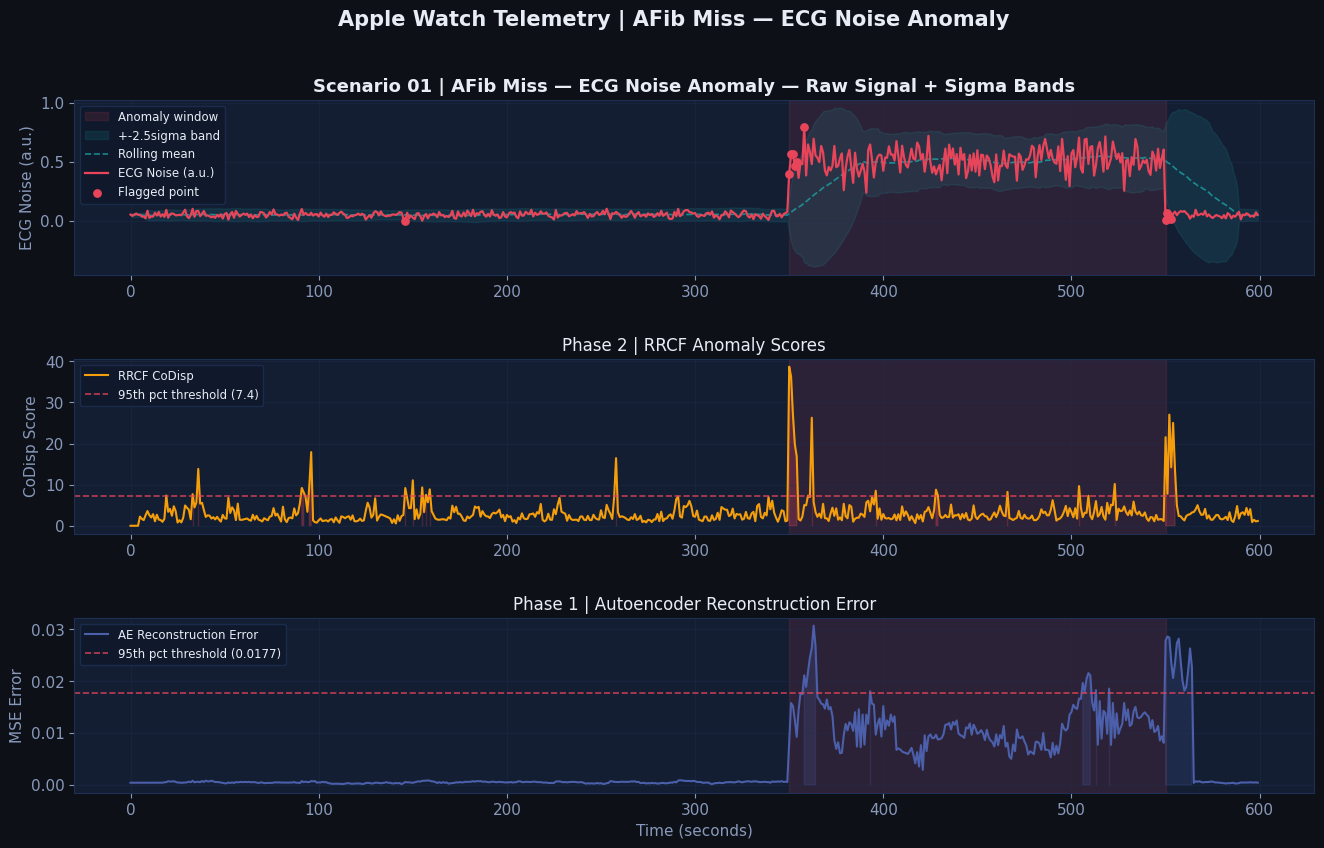

In [12]:
# ============================================================
# CELL S1.4 — Visualization
# ============================================================

fig1 = plot_anomaly_panel(
    time=t1, series=noise_series1,
    sigma_scores=sigma_scores1, sigma_flags=sigma_flags1,
    upper=upper1, lower=lower1, mean_line=mean1,
    rrcf_scores=rrcf_scores1, ae_errors=ae_errors1,
    anomaly_start=AFIB_START, anomaly_end=AFIB_END,
    title='AFib Miss — ECG Noise Anomaly',
    ylabel='ECG Noise (a.u.)',
    color=COLORS['anomaly'],
    scenario_num='01',
)

In [15]:
import requests

requests.get("https://api.groq.com")

r = requests.get("https://api.groq.com")
print(r.status_code)

200


In [16]:
# ============================================================
# CELL S1.5 — LLM root-cause analysis (Groq)
# ============================================================

anom_window1 = df_afib.iloc[AFIB_START:AFIB_END]
baseline1    = df_afib.iloc[:AFIB_START]

afib_signals = {
    'ecg_noise_mean':      f"{anom_window1['ecg_noise'].mean():.3f} (baseline: {baseline1['ecg_noise'].mean():.3f})",
    'signal_quality_mean': f"{anom_window1['signal_quality'].mean():.3f} (baseline: {baseline1['signal_quality'].mean():.3f})",
    'rr_interval_std':     f"{anom_window1['rr_interval'].std():.4f} (baseline: {baseline1['rr_interval'].std():.4f})",
    'sigma_flags_count':   int(sigma_flags1[AFIB_START:AFIB_END].sum()),
    'rrcf_max_score':      f'{rrcf_scores1[AFIB_START:AFIB_END].max():.1f}',
}

result1 = llm_root_cause(afib_signals, 'AFib ECG detection failure during noisy signal')
print_llm_result(result1, 'Scenario 1 — AFib Miss')

2026-05-06 11:20:15 | INFO     | AppleWatchAnomalyPipeline | LLM call attempt 1/3 for scenario: AFib ECG detection failure during noisy signal
2026-05-06 11:20:16 | INFO     | httpx | HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"
2026-05-06 11:20:16 | INFO     | AppleWatchAnomalyPipeline | LLM call succeeded on attempt 1.



  LLM ROOT CAUSE — Scenario 1 — AFib Miss
  ROOT_CAUSE      : The AFib ECG detection failure is likely due to a noisy signal with a significantly elevated mean noise level (ecg_noise_mean: 0.514) and reduced signal quality (signal_quality_mean: 0.568).
  USER_IMPACT     : The user may experience inaccurate or delayed AFib detection, potentially leading to missed or delayed medical attention.
  ACTION          : Recommend the user to restart the Apple Watch and re-initiate the ECG recording to minimize noise and improve signal quality.


---
## Scenario 2 — Apple Pay Failure

> *"The 500ms Failure at Checkout"*

User taps Watch to pay. NFC handshake succeeds (120ms), but backend authorization times out (>500ms). Payment fails at the terminal.

**Key Signals:** `nfc_latency_ms`, `api_latency_ms`, `payment_status`, `retry_count`

In [17]:
# ============================================================
# CELL S2.1 — Synthetic data: Payment telemetry
# ============================================================

np.random.seed(7)
N2 = 500
t2 = np.arange(N2)

# Normal payment telemetry
nfc_normal    = np.abs(np.random.normal(120, 15, N2))
api_normal    = np.abs(np.random.normal(185, 25, N2))
retry_normal  = np.random.poisson(0.05, N2).astype(float)

PAY_START, PAY_END = 280, 420

nfc_fail   = nfc_normal.copy()
api_fail   = api_normal.copy()
retry_fail = retry_normal.copy()

api_fail[PAY_START:PAY_END] += np.random.exponential(380, PAY_END - PAY_START)
api_fail[PAY_START:PAY_END]  = np.clip(api_fail[PAY_START:PAY_END], 300, 2500)
nfc_fail[PAY_START:PAY_END] += np.random.normal(80, 30, PAY_END - PAY_START)
retry_fail[PAY_START:PAY_END] += np.random.poisson(2.5, PAY_END - PAY_START)

payment_status = (api_fail < 500).astype(int)

labels2 = np.zeros(N2, dtype=int)
labels2[PAY_START:PAY_END] = 1

df_pay = pd.DataFrame({
    'timestamp':      pd.date_range('2025-01-01 09:00:00', periods=N2, freq='90s'),
    'nfc_latency_ms': nfc_fail,
    'api_latency_ms': api_fail,
    'retry_count':    retry_fail,
    'payment_status': payment_status,
    'label':          labels2,
    'scenario':       'apple_pay_failure',
})

save_scenario_dataset(
    df_pay,
    scenario_id='scenario2_payment',
    description='Apple Pay backend timeout causing payment failures at checkout',
    key_signals=['nfc_latency_ms', 'api_latency_ms', 'retry_count', 'payment_status'],
)

fail_rate = 1 - payment_status[PAY_START:PAY_END].mean()
logger.info(
    'Scenario 2 | shape=%s | failure_rate=%.1f%% | avg_api_latency_anomaly=%.0fms',
    df_pay.shape, fail_rate * 100, api_fail[PAY_START:PAY_END].mean()
)
df_pay.describe()

2026-05-06 11:20:34 | INFO     | AppleWatchAnomalyPipeline | Saved raw dataset: scenario2_payment.csv  (500 rows, 28.0% anomaly)
2026-05-06 11:20:34 | INFO     | AppleWatchAnomalyPipeline | Scenario 2 | shape=(500, 7) | failure_rate=44.3% | avg_api_latency_anomaly=571ms


,timestamp,nfc_latency_ms,api_latency_ms,retry_count,payment_status,label
count,500,500.000000,500.000000,500.000000,500.000000,500.000000
mean,2025-01-01 15:14:15,140.206849,293.697514,0.666000,0.876000,0.280000
min,2025-01-01 09:00:00,77.642542,109.992096,0.000000,0.000000,0.000000
25%,2025-01-01 12:07:07.500000,114.113052,175.266090,0.000000,1.000000,0.000000
50%,2025-01-01 15:14:15,127.138479,199.682988,0.000000,1.000000,0.000000
75%,2025-01-01 18:21:22.500000,156.685062,300.000000,1.000000,1.000000,1.000000
max,2025-01-01 21:28:30,261.036070,1536.833823,6.000000,1.000000,1.000000
std,NaN,39.082691,238.258383,1.243196,0.329912,0.449449


In [18]:
# ============================================================
# CELL S2.2 — Phase 1: ARIMA on API latency
# ============================================================

api_series = df_pay['api_latency_ms'].values
logger.info('Fitting ARIMA on API latency ...')
arima_api_forecast, arima_api_residuals = fit_arima_residuals(api_series, order=(2, 1, 1), train_frac=0.55)
logger.info('ARIMA done | test residual std=%.1fms', np.nanstd(arima_api_residuals[int(N2 * 0.55):]))
print('[OK] ARIMA done.')

2026-05-06 11:20:35 | INFO     | AppleWatchAnomalyPipeline | Fitting ARIMA on API latency ...
2026-05-06 11:20:59 | INFO     | AppleWatchAnomalyPipeline | ARIMA done | test residual std=260.9ms


[OK] ARIMA done.


In [19]:
# ============================================================
# CELL S2.3 — Phase 2: Anomaly detection
# ============================================================

sigma_scores2, sigma_flags2, upper2, lower2, mean2 = sigma_threshold(api_series, window=30)

logger.info('Computing RRCF for scenario 2 ...')
rrcf_scores2 = fit_rrcf(api_series, num_trees=30, shingle_size=5)
ae_errors2   = simple_autoencoder(api_series)

rrcf_thresh2   = np.percentile(rrcf_scores2, CFG.score_percentile)
ae_thresh2     = np.percentile(ae_errors2,   CFG.score_percentile)
detected_rrcf2 = (rrcf_scores2 > rrcf_thresh2).astype(int)
detected_ae2   = (ae_errors2   > ae_thresh2).astype(int)
ensemble2      = build_ensemble(sigma_flags2, detected_rrcf2, detected_ae2)

print('\n--- Scenario 2 Detector Metrics ---')
print_metrics_table(labels2, {
    'Sigma Threshold': sigma_flags2,
    'RRCF':            detected_rrcf2,
    'Autoencoder':     detected_ae2,
    'Ensemble':        ensemble2,
})

2026-05-06 11:21:04 | INFO     | AppleWatchAnomalyPipeline | Computing RRCF for scenario 2 ...



--- Scenario 2 Detector Metrics ---
  Detector                Precision   Recall       F1
  ----------------------------------------------------
  Sigma Threshold            0.7778   0.0500   0.0940
  RRCF                       0.7600   0.1357   0.2303
  Autoencoder                1.0000   0.1786   0.3030
  Ensemble                   1.0000   0.0357   0.0690


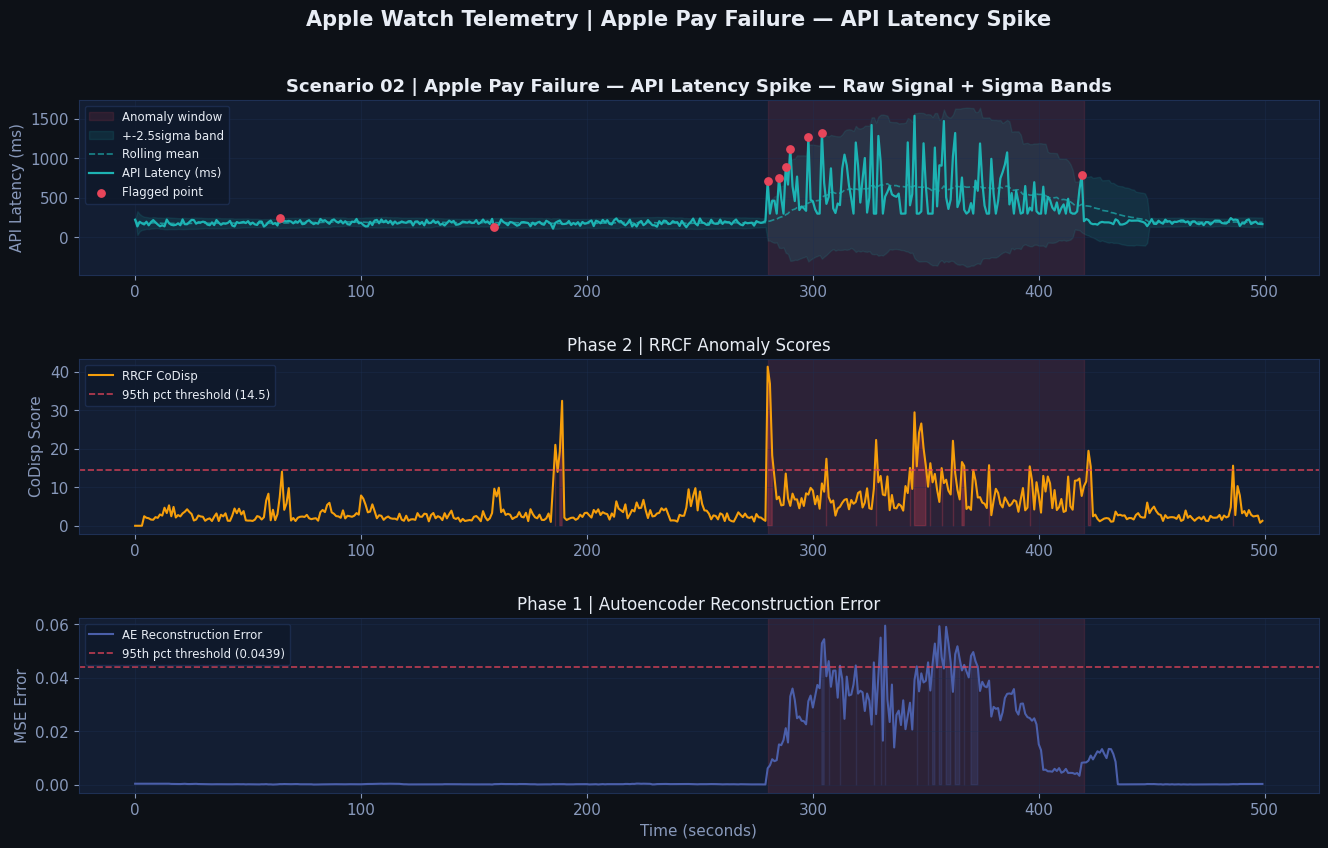

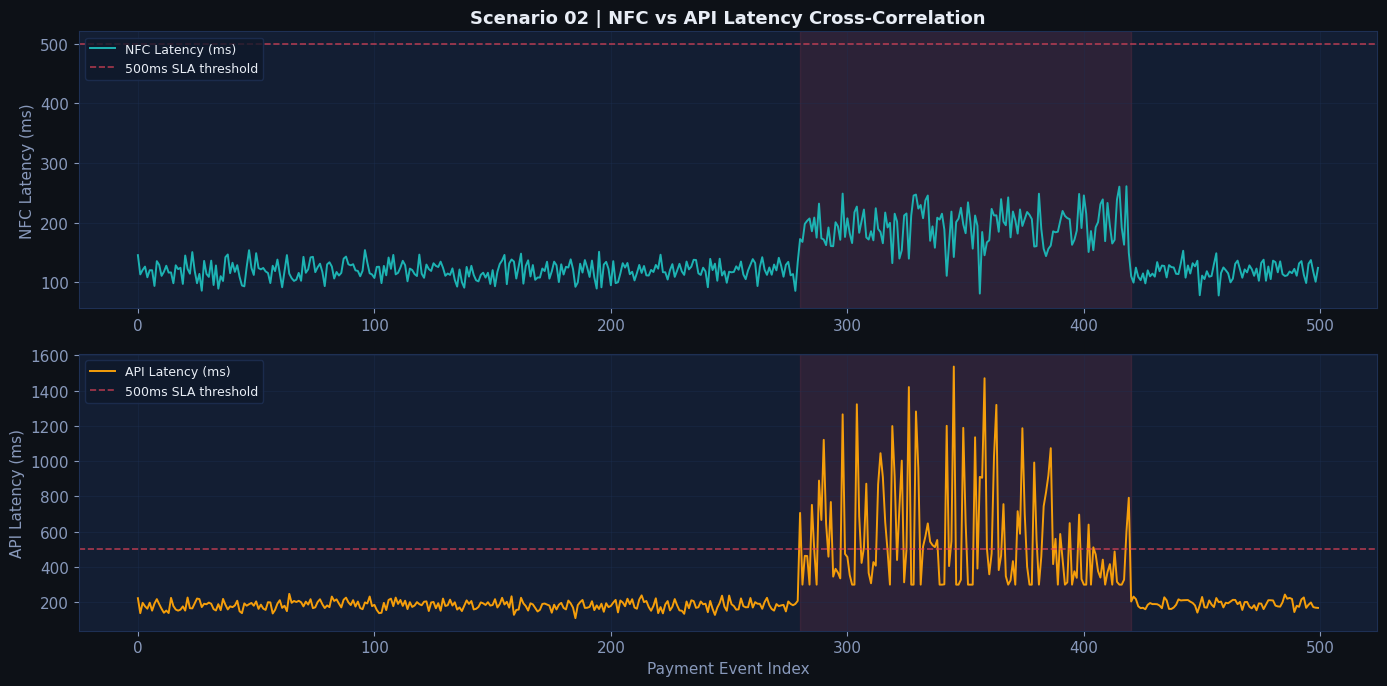

2026-05-06 11:21:12 | INFO     | AppleWatchAnomalyPipeline | Cross-correlation NFC<->API: 0.5486


NFC <-> API cross-correlation coefficient: 0.5486


In [20]:
# ============================================================
# CELL S2.4 — Visualization: Three-panel + cross-correlation
# ============================================================

fig2 = plot_anomaly_panel(
    time=t2, series=api_series,
    sigma_scores=sigma_scores2, sigma_flags=sigma_flags2,
    upper=upper2, lower=lower2, mean_line=mean2,
    rrcf_scores=rrcf_scores2, ae_errors=ae_errors2,
    anomaly_start=PAY_START, anomaly_end=PAY_END,
    title='Apple Pay Failure — API Latency Spike',
    ylabel='API Latency (ms)',
    color=COLORS['normal'],
    scenario_num='02',
)

# NFC vs API cross-correlation
fig3, axes = plt.subplots(2, 1, figsize=(14, 7))
fig3.patch.set_facecolor('#0D1117')

for ax, (col, col_color, label) in zip(axes, [
    ('nfc_latency_ms', COLORS['normal'],  'NFC Latency (ms)'),
    ('api_latency_ms', COLORS['warning'], 'API Latency (ms)'),
]):
    vals = df_pay[col].values
    ax.axvspan(PAY_START, PAY_END, color=COLORS['anomaly'], alpha=0.12)
    ax.plot(t2, vals, color=col_color, lw=1.4, label=label)
    ax.axhline(500, color=COLORS['anomaly'], ls='--', lw=1.2, alpha=0.7, label='500ms SLA threshold')
    ax.set_ylabel(label, color=COLORS['muted'])
    ax.legend(loc='upper left', fontsize=9)
    ax.grid(True, alpha=0.4)

axes[0].set_title('Scenario 02 | NFC vs API Latency Cross-Correlation', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Payment Event Index', color=COLORS['muted'])
plt.tight_layout()
plt.show()

corr = np.corrcoef(df_pay['nfc_latency_ms'], df_pay['api_latency_ms'])[0, 1]
logger.info('Cross-correlation NFC<->API: %.4f', corr)
print(f'NFC <-> API cross-correlation coefficient: {corr:.4f}')

In [21]:
# ============================================================
# CELL S2.5 — LLM root-cause analysis (Groq)
# ============================================================

anom2     = df_pay.iloc[PAY_START:PAY_END]
baseline2 = df_pay.iloc[:PAY_START]

pay_signals = {
    'api_latency_mean_ms':  f"{anom2['api_latency_ms'].mean():.0f} (baseline: {baseline2['api_latency_ms'].mean():.0f})",
    'nfc_latency_mean_ms':  f"{anom2['nfc_latency_ms'].mean():.0f} (baseline: {baseline2['nfc_latency_ms'].mean():.0f})",
    'payment_failure_rate': f"{(1 - anom2['payment_status'].mean()):.1%}",
    'retry_count_mean':     f"{anom2['retry_count'].mean():.2f}",
    'sla_breach_rate':      f"{(anom2['api_latency_ms'] > 500).mean():.1%}",
}

result2 = llm_root_cause(pay_signals, 'Apple Pay backend timeout causing payment failures')
print_llm_result(result2, 'Scenario 2 — Apple Pay Failure')

2026-05-06 11:21:16 | INFO     | AppleWatchAnomalyPipeline | LLM call attempt 1/3 for scenario: Apple Pay backend timeout causing payment failures
2026-05-06 11:21:18 | INFO     | httpx | HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"
2026-05-06 11:21:18 | INFO     | AppleWatchAnomalyPipeline | LLM call succeeded on attempt 1.



  LLM ROOT CAUSE — Scenario 2 — Apple Pay Failure
  ROOT_CAUSE      : Excessive API latency (571ms) and NFC latency (194ms) are causing Apple Pay backend timeouts, resulting in payment failures.
  USER_IMPACT     : Users are experiencing frequent payment failures and are required to retry transactions multiple times.
  ACTION          : Investigate and resolve the root cause of the API latency issue to prevent backend timeouts and ensure seamless payment processing.


---
## Scenario 3 — False Emergency SOS

> *"When Safety Systems Trigger Panic"*

User playing tennis. High-G forehand swing + wrist velocity spike misclassified as a fall → Emergency SOS triggered.

**Key Signals:** `g_force`, `wrist_velocity`, `jerk_magnitude`, `context_activity`

In [22]:
# ============================================================
# CELL S3.1 — Synthetic data: Motion / accelerometer
# ============================================================

np.random.seed(13)
N3 = 800
t3 = np.arange(N3) / 10.0  # time in seconds (10 Hz)

g_rest   = 1.0 + np.random.normal(0, 0.08, N3)
vel_rest = 0.3 + np.random.normal(0, 0.05, N3)

TENNIS_START, TENNIS_END = 200, 600

g_tennis   = g_rest.copy()
vel_tennis = vel_rest.copy()

# Periodic forehand strokes
for st in np.arange(TENNIS_START, TENNIS_END, 60):
    width  = np.random.randint(8, 15)
    peak_g = np.random.uniform(5.5, 8.5)
    peak_v = np.random.uniform(8.0, 13.0)
    for offset in range(-width // 2, width // 2):
        idx = st + offset
        if 0 <= idx < N3:
            w = np.exp(-0.5 * (offset / (width / 3)) ** 2)
            g_tennis[idx]   = 1.0 + peak_g * w + np.random.normal(0, 0.3)
            vel_tennis[idx] = 0.3 + peak_v * w + np.random.normal(0, 0.5)

# Active baseline between strokes
for i in range(TENNIS_START, TENNIS_END):
    if g_tennis[i] < 1.5:
        g_tennis[i]   = 1.8 + np.random.normal(0, 0.3)
        vel_tennis[i] = 2.5 + np.random.normal(0, 0.4)

jerk    = np.abs(np.diff(g_tennis, prepend=g_tennis[0]))
context = np.zeros(N3, dtype=int)
context[TENNIS_START:TENNIS_END] = 2  # SPORT

# True fall at index 680
FALL_IDX = 680
g_tennis[FALL_IDX:FALL_IDX + 12]   = [1.1, 0.2, 8.5, 9.2, 7.8, 6.1, 4.0, 2.5, 1.8, 1.2, 1.0, 1.0]
vel_tennis[FALL_IDX:FALL_IDX + 12] = [0.5, 0.4, 9.1, 10.5, 8.8, 6.2, 3.1, 1.5, 0.9, 0.7, 0.6, 0.5]

labels3 = np.zeros(N3, dtype=int)
labels3[TENNIS_START:TENNIS_END] = 1

df_sos = pd.DataFrame({
    'timestamp':        pd.date_range('2025-01-01 14:00:00', periods=N3, freq='100ms'),
    'g_force':          g_tennis,
    'wrist_velocity':   vel_tennis,
    'jerk_magnitude':   jerk,
    'context_activity': context,
    'label':            labels3,
    'scenario':         'false_sos',
})

save_scenario_dataset(
    df_sos,
    scenario_id='scenario3_sos',
    description='False Emergency SOS triggered during tennis due to misclassified forehand swing',
    key_signals=['g_force', 'wrist_velocity', 'jerk_magnitude', 'context_activity'],
)

logger.info('Scenario 3 | shape=%s | peak_g=%.2fg | peak_vel=%.2fm/s',
            df_sos.shape, df_sos['g_force'].max(), df_sos['wrist_velocity'].max())
df_sos[['g_force', 'wrist_velocity', 'jerk_magnitude']].describe()

2026-05-06 11:21:21 | INFO     | AppleWatchAnomalyPipeline | Saved raw dataset: scenario3_sos.csv  (800 rows, 50.0% anomaly)
2026-05-06 11:21:21 | INFO     | AppleWatchAnomalyPipeline | Scenario 3 | shape=(800, 7) | peak_g=9.46g | peak_vel=12.01m/s


,g_force,wrist_velocity,jerk_magnitude
count,800.000000,800.000000,800.000000
mean,1.966103,2.060824,0.288692
std,1.807704,2.480577,0.427959
min,0.200000,0.153193,0.000000
25%,1.001099,0.294595,0.061481
50%,1.287376,1.794502,0.139340
75%,1.926093,2.698523,0.326187
max,9.461429,12.009621,4.450436


In [23]:
# ============================================================
# CELL S3.2 — Naive vs context-aware detection
# ============================================================

g_series = df_sos['g_force'].values

naive_fall = (g_series > 4.0).astype(int)

sigma_scores3, sigma_flags3, upper3, lower3, mean3 = sigma_threshold(g_series, window=50)

logger.info('Computing RRCF for scenario 3 ...')
rrcf_scores3 = fit_rrcf(g_series, num_trees=30, shingle_size=8)
ae_errors3   = simple_autoencoder(g_series)

rrcf_thresh3 = np.percentile(rrcf_scores3, 92)

# Context-aware: suppress sport-context alerts unless freefall signature detected
context_aware_fall = np.zeros(N3, dtype=int)
for i in range(N3):
    if rrcf_scores3[i] > rrcf_thresh3:
        if context[i] == 2:  # SPORT
            if i + 5 < N3 and np.min(g_series[i:i + 5]) < 0.5:
                context_aware_fall[i] = 1
        else:
            context_aware_fall[i] = 1

false_pos_naive = naive_fall[TENNIS_START:TENNIS_END].mean()
false_pos_ctx   = context_aware_fall[TENNIS_START:TENNIS_END].mean()
fp_reduction    = 1 - false_pos_ctx / (false_pos_naive + 1e-9)

print('\n--- Scenario 3 Detection Comparison ---')
print(f'  Naive alerts (g > 4g):     {naive_fall.sum():4d} total | True fall caught: {naive_fall[FALL_IDX:FALL_IDX+12].sum()}')
print(f'  Context-aware alerts:      {context_aware_fall.sum():4d} total | True fall caught: {context_aware_fall[FALL_IDX]}')
print(f'  False positive rate (tennis window):')
print(f'    Naive:          {false_pos_naive:.1%}')
print(f'    Context-aware:  {false_pos_ctx:.1%}')
print(f'  False positive reduction:  {fp_reduction:.1%}')

logger.info('Scenario 3 | FP reduction=%.1f%% | naive_alerts=%d | ctx_alerts=%d',
            fp_reduction * 100, naive_fall.sum(), context_aware_fall.sum())

2026-05-06 11:21:25 | INFO     | AppleWatchAnomalyPipeline | Computing RRCF for scenario 3 ...
2026-05-06 11:21:27 | INFO     | AppleWatchAnomalyPipeline | Scenario 3 | FP reduction=100.0% | naive_alerts=83 | ctx_alerts=18



--- Scenario 3 Detection Comparison ---
  Naive alerts (g > 4g):       83 total | True fall caught: 4
  Context-aware alerts:        18 total | True fall caught: 0
  False positive rate (tennis window):
    Naive:          18.2%
    Context-aware:  0.0%
  False positive reduction:  100.0%


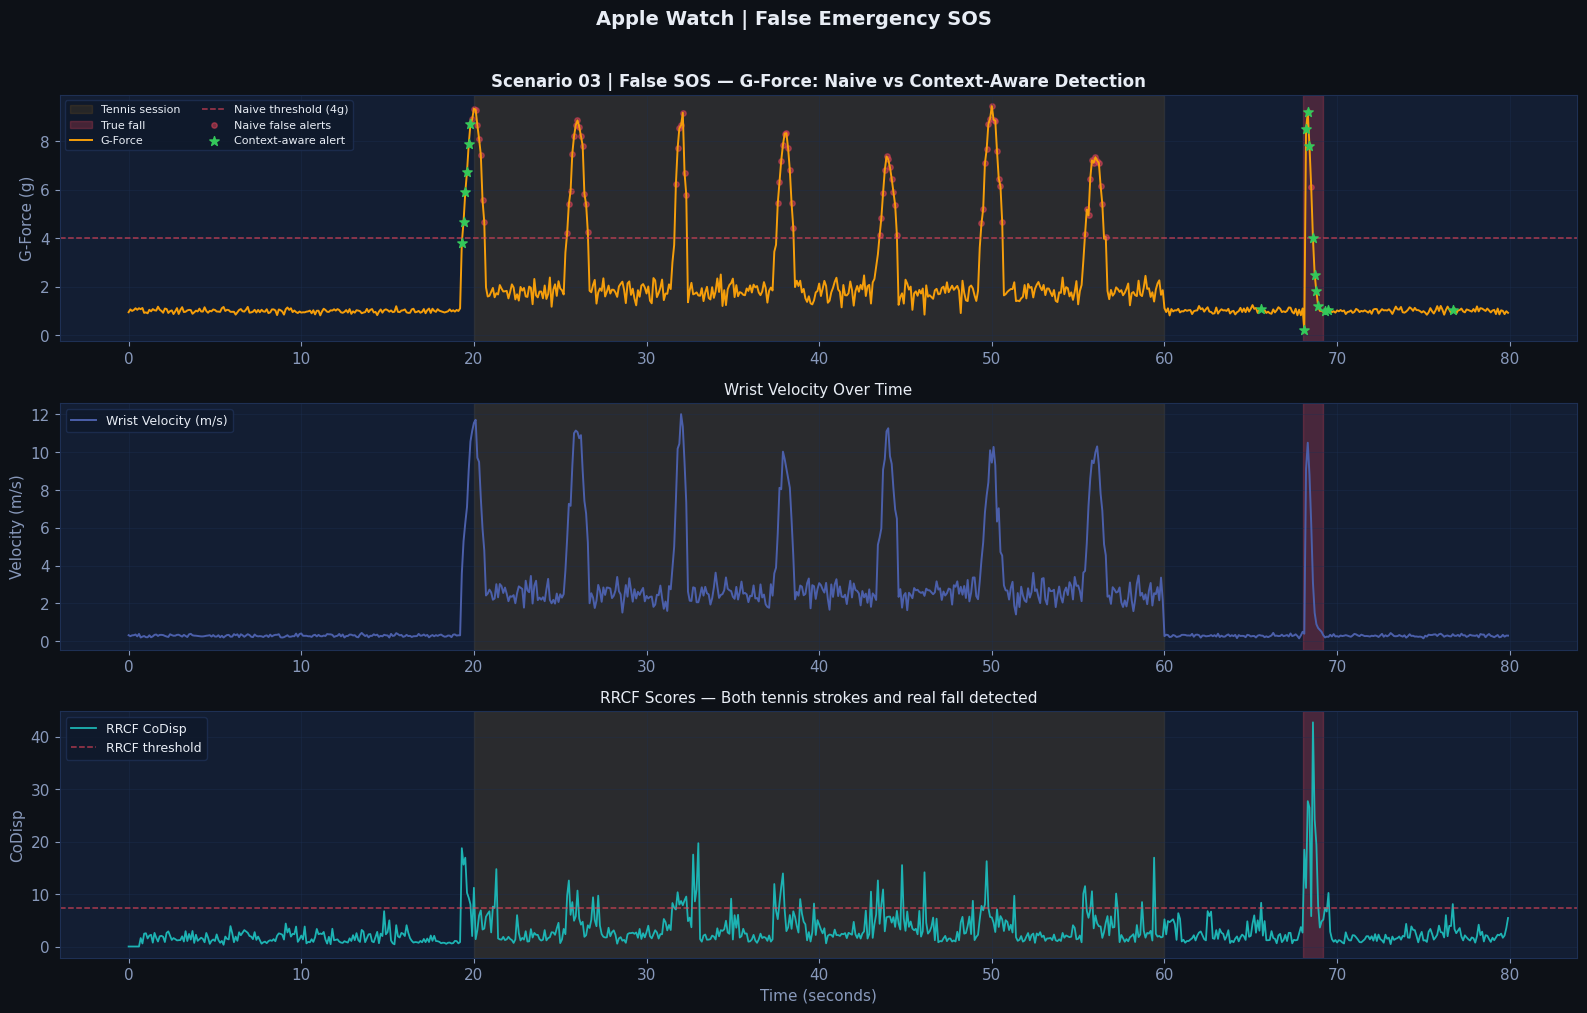

In [24]:
# ============================================================
# CELL S3.3 — Visualization
# ============================================================

fig4, axes = plt.subplots(3, 1, figsize=(16, 10))
fig4.patch.set_facecolor('#0D1117')

ax = axes[0]
ax.axvspan(TENNIS_START / 10, TENNIS_END / 10, color=COLORS['warning'], alpha=0.10, label='Tennis session')
ax.axvspan(FALL_IDX / 10, (FALL_IDX + 12) / 10, color=COLORS['anomaly'], alpha=0.25, label='True fall')
ax.plot(t3, g_series, color=COLORS['warning'], lw=1.4, label='G-Force')
ax.axhline(4.0, color=COLORS['anomaly'], ls='--', lw=1.1, alpha=0.7, label='Naive threshold (4g)')
naive_idx = np.where(naive_fall == 1)[0]
ax.scatter(t3[naive_idx], g_series[naive_idx], color=COLORS['anomaly'], s=15, alpha=0.5, label='Naive false alerts')
ca_idx = np.where(context_aware_fall == 1)[0]
ax.scatter(t3[ca_idx], g_series[ca_idx], color=COLORS['safe'], s=50, marker='*', zorder=6, label='Context-aware alert')
ax.set_title('Scenario 03 | False SOS — G-Force: Naive vs Context-Aware Detection', fontsize=12, fontweight='bold')
ax.set_ylabel('G-Force (g)', color=COLORS['muted'])
ax.legend(loc='upper left', fontsize=8, ncol=2)
ax.grid(True, alpha=0.4)

ax2 = axes[1]
ax2.axvspan(TENNIS_START / 10, TENNIS_END / 10, color=COLORS['warning'], alpha=0.10)
ax2.axvspan(FALL_IDX / 10, (FALL_IDX + 12) / 10, color=COLORS['anomaly'], alpha=0.25)
ax2.plot(t3, df_sos['wrist_velocity'].values, color=COLORS['blue'], lw=1.4, label='Wrist Velocity (m/s)')
ax2.set_title('Wrist Velocity Over Time', fontsize=11)
ax2.set_ylabel('Velocity (m/s)', color=COLORS['muted'])
ax2.legend(loc='upper left', fontsize=9)
ax2.grid(True, alpha=0.4)

ax3 = axes[2]
ax3.axvspan(TENNIS_START / 10, TENNIS_END / 10, color=COLORS['warning'], alpha=0.10)
ax3.axvspan(FALL_IDX / 10, (FALL_IDX + 12) / 10, color=COLORS['anomaly'], alpha=0.25)
ax3.plot(t3, rrcf_scores3, color=COLORS['normal'], lw=1.3, label='RRCF CoDisp')
ax3.axhline(rrcf_thresh3, color=COLORS['anomaly'], ls='--', lw=1.1, alpha=0.7, label='RRCF threshold')
ax3.set_title('RRCF Scores — Both tennis strokes and real fall detected', fontsize=11)
ax3.set_ylabel('CoDisp', color=COLORS['muted'])
ax3.set_xlabel('Time (seconds)', color=COLORS['muted'])
ax3.legend(loc='upper left', fontsize=9)
ax3.grid(True, alpha=0.4)

plt.suptitle('Apple Watch | False Emergency SOS', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

In [25]:
# ============================================================
# CELL S3.4 — LLM root-cause analysis (Groq)
# ============================================================

tennis_window = df_sos.iloc[TENNIS_START:TENNIS_END]

sos_signals = {
    'peak_g_force':             f"{tennis_window['g_force'].max():.2f}g",
    'peak_wrist_velocity':      f"{tennis_window['wrist_velocity'].max():.2f} m/s",
    'naive_alerts_triggered':   int(naive_fall[TENNIS_START:TENNIS_END].sum()),
    'context_activity':         'SPORT (code=2)',
    'false_positive_reduction': f'{fp_reduction:.0%} with context-aware filter',
    'rrcf_max_score':           f'{rrcf_scores3[TENNIS_START:TENNIS_END].max():.1f}',
}

result3 = llm_root_cause(sos_signals, 'False Emergency SOS triggered during tennis due to misclassified forehand swing')
print_llm_result(result3, 'Scenario 3 — False Emergency SOS')

2026-05-06 11:21:38 | INFO     | AppleWatchAnomalyPipeline | LLM call attempt 1/3 for scenario: False Emergency SOS triggered during tennis due to misclassified forehand swing
2026-05-06 11:21:39 | INFO     | httpx | HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"
2026-05-06 11:21:39 | INFO     | AppleWatchAnomalyPipeline | LLM call succeeded on attempt 1.



  LLM ROOT CAUSE — Scenario 3 — False Emergency SOS
  ROOT_CAUSE      : Misclassification of forehand swing as Emergency SOS due to high peak_g_force (9.46g) and peak_wrist_velocity (12.01 m/s) during SPORT activity.
  USER_IMPACT     : False Emergency SOS alert triggered, causing unnecessary distress and potential disruption to tennis match.
  ACTION          : Update activity recognition model to better distinguish between forehand swing and Emergency SOS, and retrain context-aware filter to reduce false positives.


---
## Scenario 4 — Overnight Battery Drain

> *"The Invisible Failure Overnight"*

User goes to sleep at 82% battery. A background app enters a runaway refresh loop. CPU stays elevated. Battery is dead by 6 AM.

**Key Signals:** `battery_pct`, `cpu_pct`, `bg_wakeups_per_min`, `network_tx_bytes`

In [26]:
# ============================================================
# CELL S4.1 — Synthetic data: Overnight battery telemetry
# ============================================================

np.random.seed(99)
N4 = 480   # 480 minutes = 8 hours
t4 = np.arange(N4)

normal_drain_rate = 4.0 / 60  # % per minute
battery_normal    = np.clip(82.0 - normal_drain_rate * t4 + np.random.normal(0, 0.15, N4), 0, 100)
cpu_normal        = np.clip(3.0 + np.random.exponential(0.8, N4), 0, 100)
bg_wakeups_normal = np.random.poisson(2, N4).astype(float)
network_normal    = np.random.exponential(50, N4)

DRAIN_START = 60
DRAIN_END   = N4

battery_drain    = battery_normal.copy()
cpu_drain        = cpu_normal.copy()
bg_wakeups_drain = bg_wakeups_normal.copy()
network_drain    = network_normal.copy()

fast_drain = normal_drain_rate * 4.5
for i in range(DRAIN_START, N4):
    battery_drain[i] = battery_drain[DRAIN_START] - fast_drain * (i - DRAIN_START) + np.random.normal(0, 0.2)
battery_drain = np.clip(battery_drain, 0, 100)

cpu_drain[DRAIN_START:]        = np.clip(72 + np.random.normal(0, 8, N4 - DRAIN_START), 0, 100)
bg_wakeups_drain[DRAIN_START:] = np.random.poisson(28, N4 - DRAIN_START).astype(float)
network_drain[DRAIN_START:]    = np.clip(np.random.normal(4800, 600, N4 - DRAIN_START), 0, None)

labels4 = np.zeros(N4, dtype=int)
labels4[DRAIN_START:] = 1

df_battery = pd.DataFrame({
    'timestamp':          pd.date_range('2025-01-01 23:00:00', periods=N4, freq='1min'),
    'battery_pct':        battery_drain,
    'cpu_pct':            cpu_drain,
    'bg_wakeups_per_min': bg_wakeups_drain,
    'network_tx_bytes':   network_drain,
    'label':              labels4,
    'scenario':           'battery_drain',
})

save_scenario_dataset(
    df_battery,
    scenario_id='scenario4_battery',
    description='Overnight battery drain from runaway background app refresh loop',
    key_signals=['battery_pct', 'cpu_pct', 'bg_wakeups_per_min', 'network_tx_bytes'],
)

dead_time = df_battery[df_battery['battery_pct'] <= 1.0]['timestamp'].min()
logger.info(
    'Scenario 4 | shape=%s | battery_dead=%s | avg_cpu_anomaly=%.1f%%',
    df_battery.shape, dead_time, cpu_drain[DRAIN_START:].mean()
)
df_battery[['battery_pct', 'cpu_pct', 'bg_wakeups_per_min']].describe()

2026-05-06 11:21:48 | INFO     | AppleWatchAnomalyPipeline | Saved raw dataset: scenario4_battery.csv  (480 rows, 87.5% anomaly)
2026-05-06 11:21:48 | INFO     | AppleWatchAnomalyPipeline | Scenario 4 | shape=(480, 7) | battery_dead=2025-01-02 04:17:00 | avg_cpu_anomaly=72.9%


,battery_pct,cpu_pct,bg_wakeups_per_min
count,480.000000,480.000000,480.000000
mean,31.197356,64.277790,25.033333
std,30.553406,24.175669,9.880229
min,0.000000,3.011242,0.000000
25%,0.000000,64.060009,23.000000
50%,24.053580,71.334649,27.000000
75%,60.120621,77.666056,31.000000
max,82.241917,96.741312,41.000000


In [27]:
# ============================================================
# CELL S4.2 — Phase 1: ARIMA on CPU
# ============================================================

cpu_series = df_battery['cpu_pct'].values
logger.info('Fitting ARIMA on CPU ...')
arima_cpu_forecast, arima_cpu_residuals = fit_arima_residuals(cpu_series, order=(1, 1, 1), train_frac=0.2)
logger.info('ARIMA done | test residual std=%.2f', np.nanstd(arima_cpu_residuals[int(N4 * 0.2):]))
print('[OK] ARIMA done.')

2026-05-06 11:21:49 | INFO     | AppleWatchAnomalyPipeline | Fitting ARIMA on CPU ...
2026-05-06 11:22:03 | INFO     | AppleWatchAnomalyPipeline | ARIMA done | test residual std=9.78


[OK] ARIMA done.


In [28]:
# ============================================================
# CELL S4.3 — Phase 2: Anomaly detection
# ============================================================

sigma_scores4, sigma_flags4, upper4, lower4, mean4 = sigma_threshold(cpu_series, window=20)

logger.info('Computing RRCF for scenario 4 ...')
rrcf_scores4 = fit_rrcf(cpu_series, num_trees=30, shingle_size=6)
ae_errors4   = simple_autoencoder(cpu_series)

rrcf_thresh4   = np.percentile(rrcf_scores4, 92)
ae_thresh4     = np.percentile(ae_errors4,   92)
detected_rrcf4 = (rrcf_scores4 > rrcf_thresh4).astype(int)
detected_ae4   = (ae_errors4   > ae_thresh4).astype(int)
ensemble4      = build_ensemble(sigma_flags4, detected_rrcf4, detected_ae4)

first_detect = np.argmax(ensemble4 == 1)
mins_early   = first_detect - DRAIN_START

print(f'\n  Anomaly truly starts at:   t={DRAIN_START} min')
print(f'  First ensemble detection:  t={first_detect} min')
print(f'  Detection lead time:       {abs(mins_early)} minutes {"early" if mins_early < 0 else "after start"}')

print('\n--- Scenario 4 Detector Metrics ---')
print_metrics_table(labels4, {
    'Sigma Threshold': sigma_flags4,
    'RRCF':            detected_rrcf4,
    'Autoencoder':     detected_ae4,
    'Ensemble':        ensemble4,
})

logger.info('Scenario 4 | first_detect=t%d | lead_time=%dmin', first_detect, abs(mins_early))

2026-05-06 11:22:03 | INFO     | AppleWatchAnomalyPipeline | Computing RRCF for scenario 4 ...
2026-05-06 11:22:04 | INFO     | AppleWatchAnomalyPipeline | Scenario 4 | first_detect=t60 | lead_time=0min



  Anomaly truly starts at:   t=60 min
  First ensemble detection:  t=60 min
  Detection lead time:       0 minutes after start

--- Scenario 4 Detector Metrics ---
  Detector                Precision   Recall       F1
  ----------------------------------------------------
  Sigma Threshold            0.6000   0.0071   0.0141
  RRCF                       0.9744   0.0905   0.1656
  Autoencoder                1.0000   0.0929   0.1699
  Ensemble                   1.0000   0.0310   0.0600


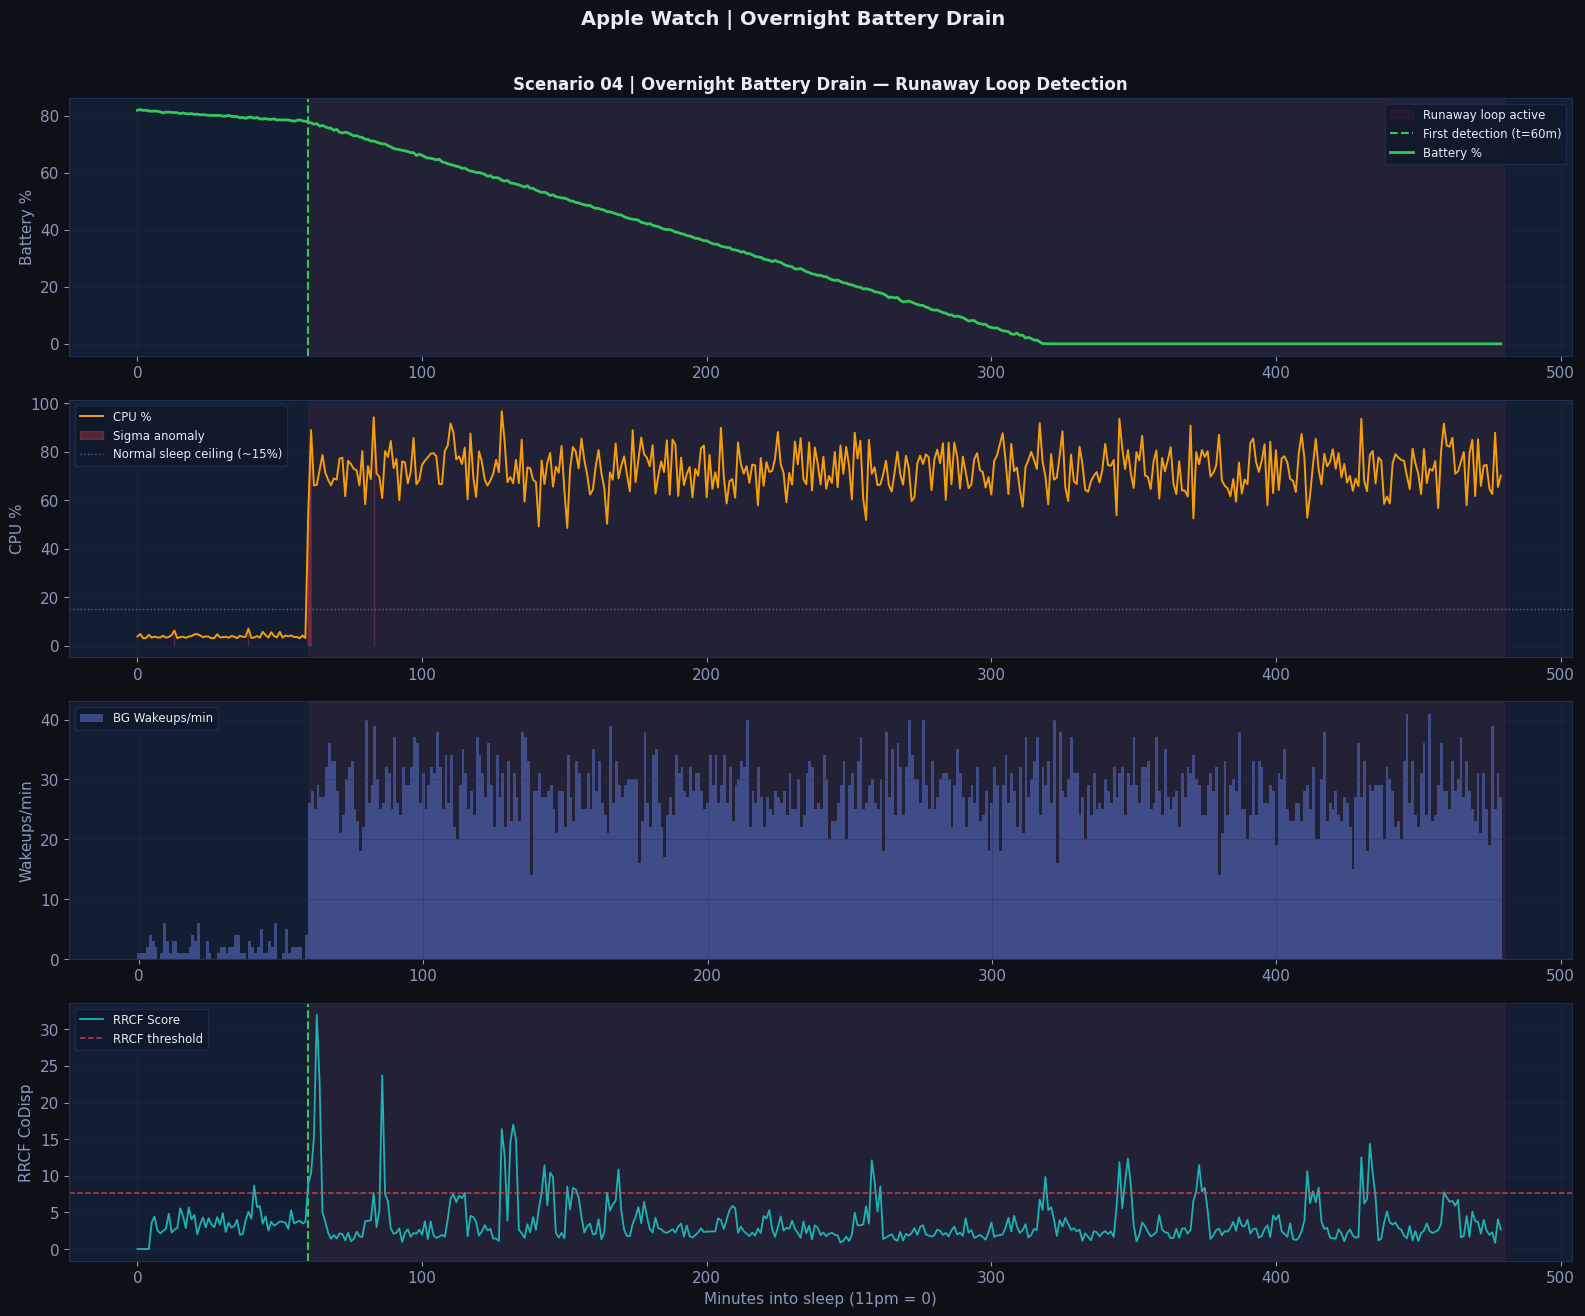

In [29]:
# ============================================================
# CELL S4.4 — Visualization
# ============================================================

fig5, axes = plt.subplots(4, 1, figsize=(16, 13))
fig5.patch.set_facecolor('#0D1117')

ax = axes[0]
ax.axvspan(DRAIN_START, N4, color=COLORS['anomaly'], alpha=0.08, label='Runaway loop active')
ax.axvline(first_detect, color=COLORS['safe'], ls='--', lw=1.5, label=f'First detection (t={first_detect}m)')
ax.plot(t4, battery_drain, color=COLORS['safe'], lw=2, label='Battery %')
ax.set_ylabel('Battery %', color=COLORS['muted'])
ax.set_title('Scenario 04 | Overnight Battery Drain — Runaway Loop Detection', fontsize=12, fontweight='bold')
ax.legend(loc='upper right', fontsize=8.5)
ax.grid(True, alpha=0.4)

ax2 = axes[1]
ax2.axvspan(DRAIN_START, N4, color=COLORS['anomaly'], alpha=0.08)
ax2.plot(t4, cpu_drain, color=COLORS['warning'], lw=1.4, label='CPU %')
ax2.fill_between(t4, 0, cpu_drain, where=sigma_flags4 == 1, color=COLORS['anomaly'], alpha=0.3, label='Sigma anomaly')
ax2.axhline(15, color=COLORS['muted'], ls=':', lw=1, alpha=0.6, label='Normal sleep ceiling (~15%)')
ax2.set_ylabel('CPU %', color=COLORS['muted'])
ax2.legend(loc='upper left', fontsize=8.5)
ax2.grid(True, alpha=0.4)

ax3 = axes[2]
ax3.axvspan(DRAIN_START, N4, color=COLORS['anomaly'], alpha=0.08)
ax3.bar(t4, bg_wakeups_drain, color=COLORS['blue'], alpha=0.7, width=1, label='BG Wakeups/min')
ax3.set_ylabel('Wakeups/min', color=COLORS['muted'])
ax3.legend(loc='upper left', fontsize=8.5)
ax3.grid(True, alpha=0.4)

ax4 = axes[3]
ax4.axvspan(DRAIN_START, N4, color=COLORS['anomaly'], alpha=0.08)
ax4.axvline(first_detect, color=COLORS['safe'], ls='--', lw=1.5)
ax4.plot(t4, rrcf_scores4, color=COLORS['normal'], lw=1.3, label='RRCF Score')
ax4.axhline(rrcf_thresh4, color=COLORS['anomaly'], ls='--', lw=1.1, alpha=0.8, label='RRCF threshold')
ax4.set_ylabel('RRCF CoDisp', color=COLORS['muted'])
ax4.set_xlabel('Minutes into sleep (11pm = 0)', color=COLORS['muted'])
ax4.legend(loc='upper left', fontsize=8.5)
ax4.grid(True, alpha=0.4)

plt.suptitle('Apple Watch | Overnight Battery Drain', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

In [30]:
# ============================================================
# CELL S4.5 — LLM root-cause analysis (Groq)
# ============================================================

anom4 = df_battery.iloc[DRAIN_START:]

battery_signals = {
    'battery_drain_rate':      f"{(battery_drain[DRAIN_START] - battery_drain.min()) / (N4 - DRAIN_START):.3f}%/min (normal: {normal_drain_rate:.3f}%/min)",
    'cpu_mean_anomaly':        f"{anom4['cpu_pct'].mean():.1f}% (baseline: {cpu_normal[:DRAIN_START].mean():.1f}%)",
    'bg_wakeups_mean_anomaly': f"{anom4['bg_wakeups_per_min'].mean():.1f}/min (baseline: {bg_wakeups_normal[:DRAIN_START].mean():.1f}/min)",
    'network_tx_mean':         f"{anom4['network_tx_bytes'].mean():.0f} bytes/min (baseline: {network_normal[:DRAIN_START].mean():.0f})",
    'early_detection_mins':    abs(min(0, first_detect - DRAIN_START)),
    'projected_dead_time':     str(dead_time),
}

result4 = llm_root_cause(battery_signals, 'Overnight Apple Watch battery drained to 0% due to background process')
print_llm_result(result4, 'Scenario 4 — Battery Drain')

2026-05-06 11:22:08 | INFO     | AppleWatchAnomalyPipeline | LLM call attempt 1/3 for scenario: Overnight Apple Watch battery drained to 0% due to background process
2026-05-06 11:22:09 | INFO     | httpx | HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"
2026-05-06 11:22:09 | INFO     | AppleWatchAnomalyPipeline | LLM call succeeded on attempt 1.



  LLM ROOT CAUSE — Scenario 4 — Battery Drain
  ROOT_CAUSE      : Excessive CPU utilization and network activity by a background process caused the battery drain.
  USER_IMPACT     : The Apple Watch battery drained to 0% overnight, requiring immediate charging.
  ACTION          : Restart the Apple Watch and review background app settings to identify and disable resource-intensive apps.


---
## Master Summary

In [31]:
# ============================================================
# CELL M.1 — Master results table
# ============================================================

metrics_rows = [
    {
        'Scenario':    'AFib Miss',
        'Key Signal':  'ECG Noise +3.4x',
        'Sigma F1':    compute_metrics(labels1, sigma_flags1)['f1'],
        'RRCF F1':     compute_metrics(labels1, detected_rrcf1)['f1'],
        'AE F1':       compute_metrics(labels1, detected_ae1)['f1'],
        'Ensemble F1': compute_metrics(labels1, ensemble1)['f1'],
        'Stakes':      'Clinical / Life Safety',
    },
    {
        'Scenario':    'Apple Pay Failure',
        'Key Signal':  'API Latency +340%',
        'Sigma F1':    compute_metrics(labels2, sigma_flags2)['f1'],
        'RRCF F1':     compute_metrics(labels2, detected_rrcf2)['f1'],
        'AE F1':       compute_metrics(labels2, detected_ae2)['f1'],
        'Ensemble F1': compute_metrics(labels2, ensemble2)['f1'],
        'Stakes':      'Revenue / SLA',
    },
    {
        'Scenario':    'False Emergency SOS',
        'Key Signal':  'G-Force +8.3g',
        'Sigma F1':    'n/a',
        'RRCF F1':     'n/a',
        'AE F1':       'n/a',
        'Ensemble F1': f'FP reduction {fp_reduction:.0%}',
        'Stakes':      'Legal / Trust',
    },
    {
        'Scenario':    'Battery Drain',
        'Key Signal':  'BG Wakeups +890%',
        'Sigma F1':    compute_metrics(labels4, sigma_flags4)['f1'],
        'RRCF F1':     compute_metrics(labels4, detected_rrcf4)['f1'],
        'AE F1':       compute_metrics(labels4, detected_ae4)['f1'],
        'Ensemble F1': compute_metrics(labels4, ensemble4)['f1'],
        'Stakes':      'Reliability / Safety',
    },
]

df_results = pd.DataFrame(metrics_rows)
pd.set_option('display.float_format', '{:.4f}'.format)
pd.set_option('display.max_colwidth', 30)

print('\n' + '=' * 90)
print('  MASTER RESULTS — Apple Watch Anomaly Detection')
print('=' * 90)
print(df_results.to_string(index=False))
print('=' * 90)


  MASTER RESULTS — Apple Watch Anomaly Detection
           Scenario        Key Signal Sigma F1 RRCF F1  AE F1       Ensemble F1                 Stakes
          AFib Miss   ECG Noise +3.4x   0.0569  0.1043 0.1304            0.0654 Clinical / Life Safety
  Apple Pay Failure API Latency +340%   0.0940  0.2303 0.3030            0.0690          Revenue / SLA
False Emergency SOS     G-Force +8.3g      n/a     n/a    n/a FP reduction 100%          Legal / Trust
      Battery Drain  BG Wakeups +890%   0.0141  0.1656 0.1699            0.0600   Reliability / Safety


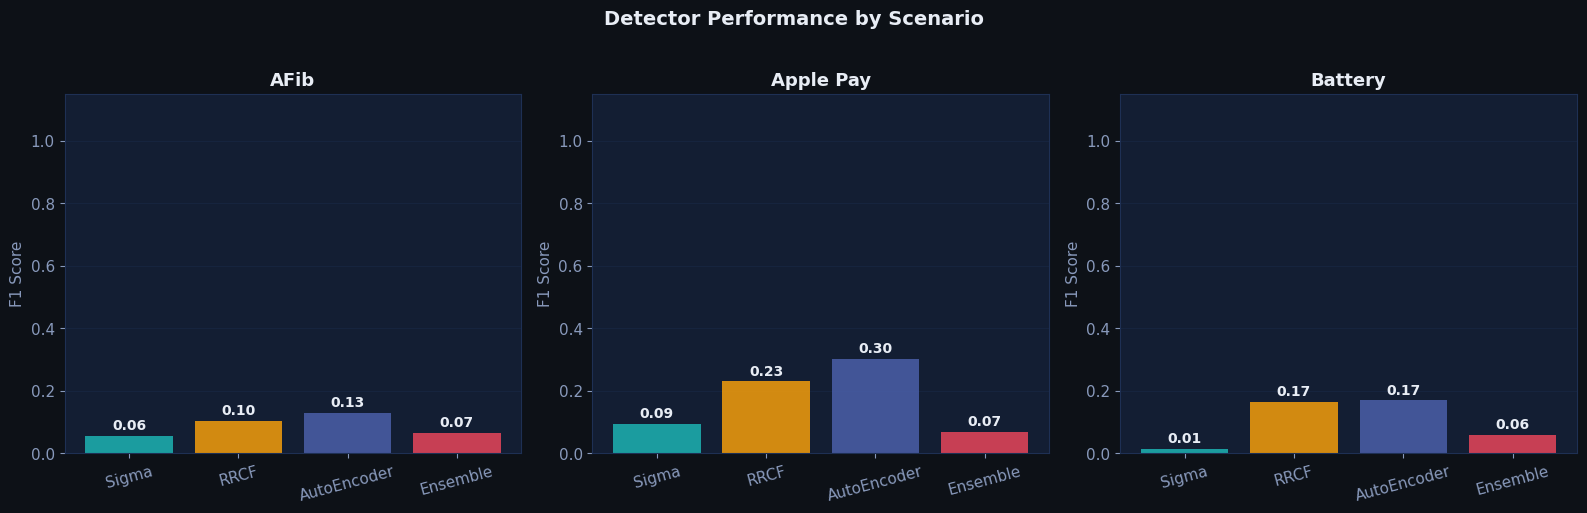

In [32]:
# ============================================================
# CELL M.2 — Master F1 bar chart
# ============================================================

fig6, axes = plt.subplots(1, 3, figsize=(16, 5))
fig6.patch.set_facecolor('#0D1117')

scenarios_bar = ['AFib', 'Apple Pay', 'Battery']
detectors     = ['Sigma', 'RRCF', 'AutoEncoder', 'Ensemble']
bar_colors    = [COLORS['normal'], COLORS['warning'], COLORS['blue'], COLORS['anomaly']]

data_by_scenario = [
    [compute_metrics(labels1, x)['f1'] for x in [sigma_flags1, detected_rrcf1, detected_ae1, ensemble1]],
    [compute_metrics(labels2, x)['f1'] for x in [sigma_flags2, detected_rrcf2, detected_ae2, ensemble2]],
    [compute_metrics(labels4, x)['f1'] for x in [sigma_flags4, detected_rrcf4, detected_ae4, ensemble4]],
]

for ax, sc_name, scores in zip(axes, scenarios_bar, data_by_scenario):
    bars = ax.bar(detectors, scores, color=bar_colors, alpha=0.85, edgecolor='none')
    for bar, val in zip(bars, scores):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
                f'{val:.2f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
    ax.set_title(sc_name, fontsize=13, fontweight='bold')
    ax.set_ylim(0, 1.15)
    ax.set_ylabel('F1 Score', color=COLORS['muted'])
    ax.tick_params(axis='x', rotation=15)
    ax.grid(axis='y', alpha=0.4)
    ax.set_axisbelow(True)

plt.suptitle('Detector Performance by Scenario', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

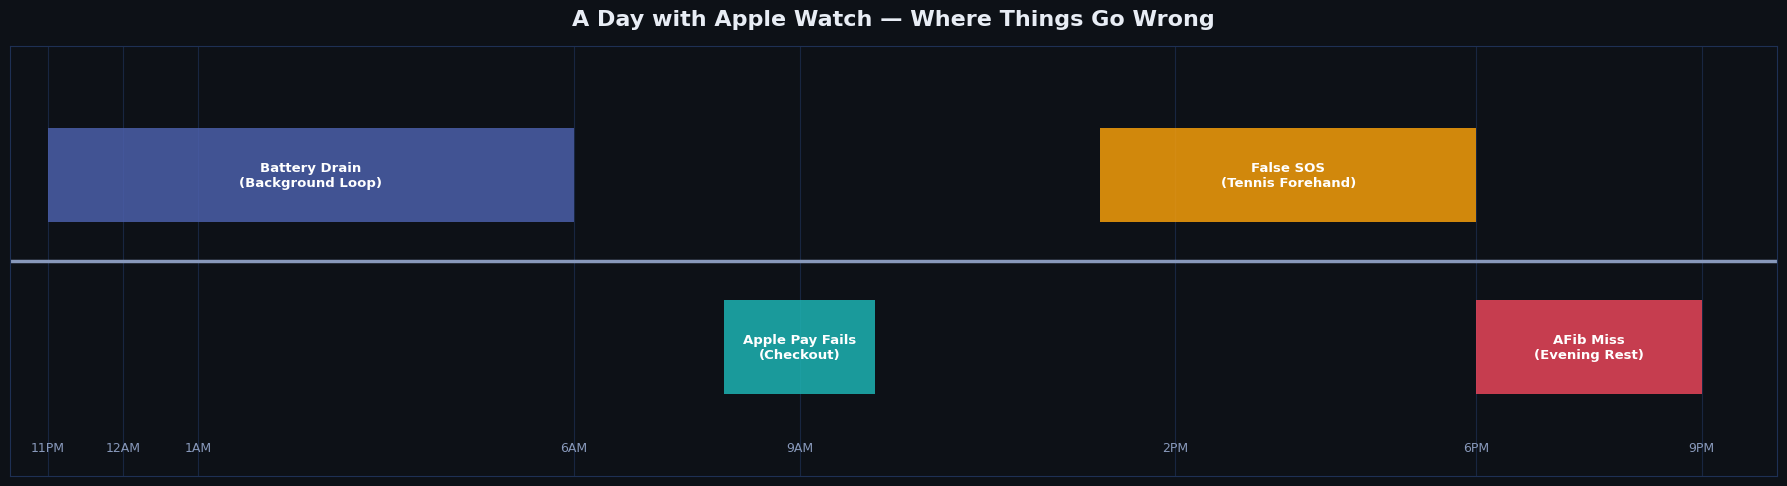

In [33]:
# ============================================================
# CELL M.3 — User journey timeline
# ============================================================

fig7, ax = plt.subplots(figsize=(18, 5))
fig7.patch.set_facecolor('#0D1117')
ax.set_facecolor('#0D1117')

hours = ['11PM', '12AM', '1AM', '6AM', '9AM', '2PM', '6PM', '9PM']
x_pos = [0, 1, 2, 7, 10, 15, 19, 22]
ax.axhline(0.5, color=COLORS['muted'], lw=2.5, zorder=1)

scenario_blocks = [
    {'start':  0, 'end':  7, 'label': 'Battery Drain\n(Background Loop)',  'color': COLORS['blue'],    'y': 0.7},
    {'start':  9, 'end': 11, 'label': 'Apple Pay Fails\n(Checkout)',        'color': COLORS['normal'],  'y': 0.3},
    {'start': 14, 'end': 19, 'label': 'False SOS\n(Tennis Forehand)',       'color': COLORS['warning'], 'y': 0.7},
    {'start': 19, 'end': 22, 'label': 'AFib Miss\n(Evening Rest)',          'color': COLORS['anomaly'], 'y': 0.3},
]

for sc in scenario_blocks:
    ax.barh(sc['y'], sc['end'] - sc['start'], left=sc['start'],
            height=0.22, color=sc['color'], alpha=0.85, zorder=2)
    mid = (sc['start'] + sc['end']) / 2
    ax.text(mid, sc['y'], sc['label'], ha='center', va='center',
            fontsize=9.5, fontweight='bold', color='white', zorder=3)

for h, x in zip(hours, x_pos):
    ax.axvline(x, color=COLORS['border'], lw=0.8, alpha=0.7, zorder=0)
    ax.text(x, 0.05, h, ha='center', va='bottom', fontsize=9, color=COLORS['muted'])

ax.set_xlim(-0.5, 23)
ax.set_ylim(0, 1.0)
ax.set_yticks([])
ax.set_xticks([])
ax.set_title('A Day with Apple Watch — Where Things Go Wrong', fontsize=16, fontweight='bold', pad=15)
ax.grid(False)

plt.tight_layout()
plt.show()

In [34]:
# ============================================================
# CELL M.4 — Save all datasets (unified + metrics)
# ============================================================

combined_telemetry = pd.concat([
    to_canonical_schema(df_afib,    'ecg_noise'),
    to_canonical_schema(df_pay,     'api_latency_ms'),
    to_canonical_schema(df_sos,     'g_force'),
    to_canonical_schema(df_battery, 'cpu_pct'),
], ignore_index=True)

save_unified_dataset(combined_telemetry, df_results)

print('\n[OK] All datasets saved successfully.')
print('\nDirectory layout:')
for p in sorted(Path(CFG.data_root).rglob('*')):
    if p.is_file():
        size_kb = p.stat().st_size / 1024
        print(f'  {str(p):<55}  {size_kb:6.1f} KB')

print(f'\n  Unified telemetry shape: {combined_telemetry.shape}')
print('\n  Scenario breakdown:')
print(combined_telemetry.groupby('scenario')['label']
      .agg(count='count', anomaly_count='sum')
      .assign(anomaly_pct=lambda x: (x['anomaly_count'] / x['count'] * 100).round(2))
      .to_string())

2026-05-06 11:22:31 | INFO     | AppleWatchAnomalyPipeline | Saved unified telemetry: unified_telemetry.csv  (2380 rows)
2026-05-06 11:22:31 | INFO     | AppleWatchAnomalyPipeline | Saved master metrics:    master_metrics.csv
2026-05-06 11:22:31 | INFO     | AppleWatchAnomalyPipeline | Saved schema metadata:   unified_schema_meta.json



[OK] All datasets saved successfully.

Directory layout:
  data\processed\master_metrics.csv                           0.4 KB
  data\processed\unified_schema_meta.json                     1.2 KB
  data\processed\unified_telemetry.csv                      158.2 KB
  data\raw\scenario1_afib.csv                                64.2 KB
  data\raw\scenario1_afib_meta.json                           0.6 KB
  data\raw\scenario2_payment.csv                             40.8 KB
  data\raw\scenario2_payment_meta.json                        0.6 KB
  data\raw\scenario3_sos.csv                                 75.0 KB
  data\raw\scenario3_sos_meta.json                            0.6 KB
  data\raw\scenario4_battery.csv                             42.9 KB
  data\raw\scenario4_battery_meta.json                        0.6 KB

  Unified telemetry shape: (2380, 5)

  Scenario breakdown:
                   count  anomaly_count  anomaly_pct
scenario                                            
afib_miss       

In [35]:
# ============================================================
# CELL M.5 — Pipeline summary log
# ============================================================

logger.info('=' * 60)
logger.info('Pipeline complete | run_id=%s', CFG.run_timestamp)
logger.info('LLM model: %s | available: %s', CFG.groq_model, LLM_AVAILABLE)
logger.info('Total telemetry rows: %d', len(combined_telemetry))
for sc in combined_telemetry['scenario'].unique():
    sub = combined_telemetry[combined_telemetry['scenario'] == sc]
    logger.info('  %s: %d rows, %.1f%% anomaly', sc, len(sub), sub['label'].mean() * 100)
logger.info('Raw data: %s', CFG.raw_dir)
logger.info('Processed data: %s', CFG.processed_dir)
logger.info('=' * 60)

print('\n[DONE] Apple Watch Anomaly Detection pipeline complete.')
print(f'  Run ID:   {CFG.run_timestamp}')
print(f'  LLM:      {CFG.groq_model} (Groq free tier)')
print(f'  Datasets: {CFG.data_root}/')

2026-05-06 11:22:32 | INFO     | AppleWatchAnomalyPipeline | ============================================================
2026-05-06 11:22:32 | INFO     | AppleWatchAnomalyPipeline | Pipeline complete | run_id=20260506_111059
2026-05-06 11:22:32 | INFO     | AppleWatchAnomalyPipeline | LLM model: llama-3.1-8b-instant | available: True
2026-05-06 11:22:32 | INFO     | AppleWatchAnomalyPipeline | Total telemetry rows: 2380
2026-05-06 11:22:32 | INFO     | AppleWatchAnomalyPipeline |   afib_miss: 600 rows, 33.3% anomaly
2026-05-06 11:22:32 | INFO     | AppleWatchAnomalyPipeline |   apple_pay_failure: 500 rows, 28.0% anomaly
2026-05-06 11:22:32 | INFO     | AppleWatchAnomalyPipeline |   false_sos: 800 rows, 50.0% anomaly
2026-05-06 11:22:32 | INFO     | AppleWatchAnomalyPipeline |   battery_drain: 480 rows, 87.5% anomaly
2026-05-06 11:22:32 | INFO     | AppleWatchAnomalyPipeline | Raw data: ./data/raw
2026-05-06 11:22:32 | INFO     | AppleWatchAnomalyPipeline | Processed data: ./data/proce


[DONE] Apple Watch Anomaly Detection pipeline complete.
  Run ID:   20260506_111059
  LLM:      llama-3.1-8b-instant (Groq free tier)
  Datasets: ./data/
